# Luas Green Line × RTB Rent Index — analysis

Four questions:

1. How does rent vary along the line — and does the headline average lie?
2. How have rents moved since 2008 relative to Dublin as a whole?
3. **The gradient**: how much does a minute of commute (or one more stop)
   actually knock off the rent?
4. Which stations give the best value for money, and where are the
   "price cliffs" between neighbouring stops?

SQL does the heavy lifting (the queries live in `database/queries/`),
Python does the statistics and charts.

In [1]:
import sys
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt

ROOT = Path.cwd() if (Path.cwd() / "src").exists() else Path.cwd().parent
sys.path.append(str(ROOT / "src"))

from sql_utils import run_sql, run_query_file

pd.set_option("display.max_columns", None)

import numpy as np

from analysis import fit_gradient, gradient_by_year, eur_per_stop, MINUTES_PER_STOP
from visualize import save_fig, station_rent_map, save_map

SLICE = "1 to 2 bed"   # only bedroom slice published for every area (see exploration notebook)

## 1. Rent along the line — and why the headline number misleads

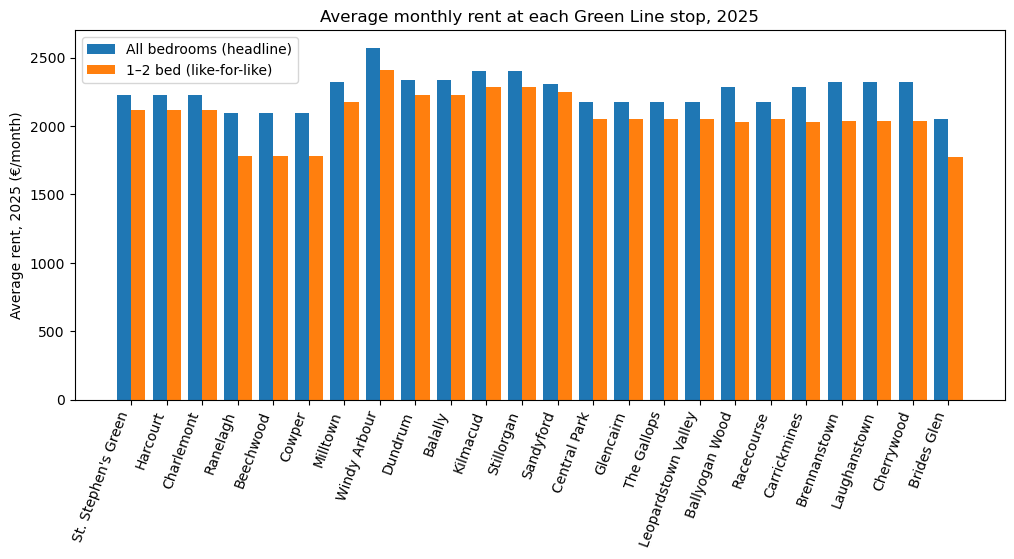

In [2]:
line_2025 = run_sql("""
    SELECT stop_sequence, station, travel_min_to_centre, bedrooms, avg_rent
    FROM station_rents
    WHERE year = 2025
      AND property_type = 'All property types'
      AND bedrooms IN ('All bedrooms', '1 to 2 bed')
""")
pivot = (line_2025
         .pivot_table(index=["stop_sequence", "station"], columns="bedrooms", values="avg_rent")
         .reset_index())

fig, ax = plt.subplots(figsize=(12, 4.8))
x = pivot["stop_sequence"]
ax.bar(x - 0.2, pivot["All bedrooms"], width=0.4, label="All bedrooms (headline)")
ax.bar(x + 0.2, pivot["1 to 2 bed"], width=0.4, label="1–2 bed (like-for-like)")
ax.set_xticks(x)
ax.set_xticklabels(pivot["station"], rotation=70, ha="right")
ax.set_ylabel("Average rent, 2025 (€/month)")
ax.set_title("Average monthly rent at each Green Line stop, 2025")
ax.legend()
save_fig(fig, "rent_along_line")
plt.show()

The headline series (blue) is almost flat — and in places *higher* in the
suburbs than in town. That is a composition effect, not a distance effect:
the suburban housing stock is dominated by larger houses, the city centre
by small apartments. Once the property size is fixed (orange), the centre
is more expensive and a real structure appears — including the odd
**Ranelagh dip**: 1–2 bed homes around Ranelagh/Beechwood/Cowper average
€1,784, *cheaper than almost everywhere else on the line* despite being
7–11 minutes from St. Stephen's Green. One likely driver: that area's
1–2 bed stock includes a lot of older subdivided flats, which pull the
average down relative to the new-build apartments further out.

## 2. Trends since 2008: the line vs the county

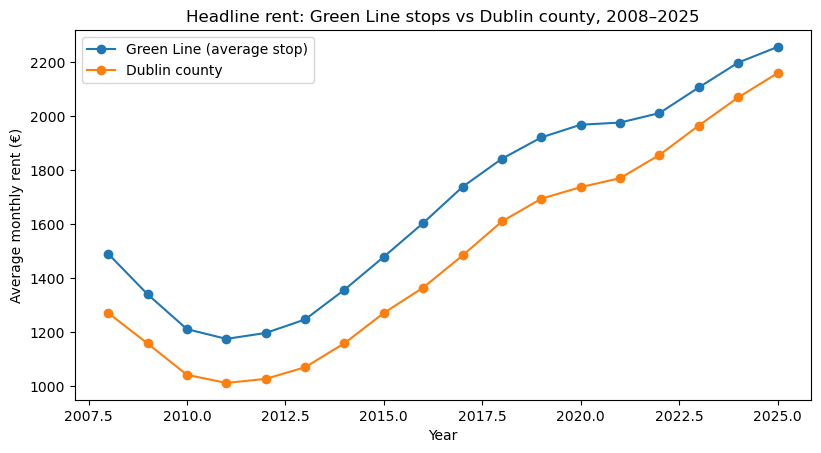

,year,line_avg,dublin_avg,premium_pct
12,2020,1968.0,1737.0,13.3
13,2021,1976.0,1770.0,11.6
14,2022,2011.0,1856.0,8.3
15,2023,2106.0,1965.0,7.2
16,2024,2198.0,2069.0,6.3
17,2025,2256.0,2159.0,4.5


In [3]:
trend = run_query_file("03")

fig, ax = plt.subplots(figsize=(9.5, 4.8))
ax.plot(trend["year"], trend["line_avg"], marker="o", label="Green Line (average stop)")
ax.plot(trend["year"], trend["dublin_avg"], marker="o", label="Dublin county")
ax.set_xlabel("Year")
ax.set_ylabel("Average monthly rent (€)")
ax.set_title("Headline rent: Green Line stops vs Dublin county, 2008–2025")
ax.legend()
save_fig(fig, "line_vs_dublin")
plt.show()

trend.tail(6)

The line tracks the county closely but sits a steady **15–19% above it**
in every single year — crash, recovery and boom alike. The premium for
living on this corridor has been remarkably stable for 18 years.

Covid is barely visible: rents in these areas didn't fall in 2020–2021,
growth just paused (the SQL query `10_covid_dip_recovery.sql` puts the
2019→2021 change between **+0.1% and +4.1%** depending on the area, after
years of ~8% annual growth).

## 3. The rent gradient: what does a minute of commute buy?

The classic urban-economics expectation: each extra minute from the
centre should shave something off the rent. Fit a simple linear
regression of 1–2 bed rent on scheduled commute time, station by station.

slope: -1.44 €/minute   intercept: €2,107   R²: 0.012
per extra stop (~1.8 min): -2.63 €


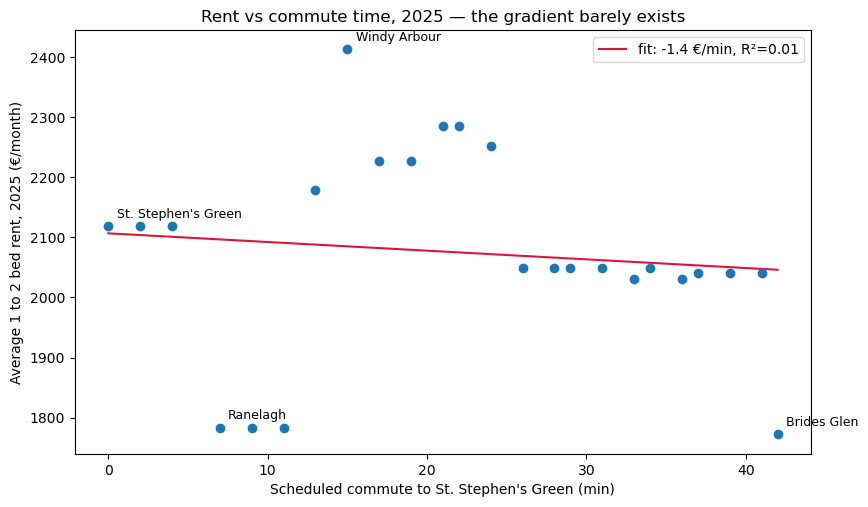

In [4]:
pts = run_sql(f"""
    SELECT station, travel_min_to_centre, avg_rent
    FROM station_rents
    WHERE year = 2025
      AND bedrooms = '{SLICE}'
      AND property_type = 'All property types'
""")

slope, intercept, r2 = fit_gradient(pts)
print(f"slope: {slope:+.2f} €/minute   intercept: €{intercept:,.0f}   R²: {r2:.3f}")
print(f"per extra stop (~{MINUTES_PER_STOP:.1f} min): {eur_per_stop(slope):+.2f} €")

fig, ax = plt.subplots(figsize=(9.5, 5.5))
ax.scatter(pts["travel_min_to_centre"], pts["avg_rent"], zorder=3)
xs = np.linspace(0, pts["travel_min_to_centre"].max(), 50)
ax.plot(xs, intercept + slope * xs, color="crimson",
        label=f"fit: {slope:+.1f} €/min, R²={r2:.2f}")
for label in ["Ranelagh", "Brides Glen", "Windy Arbour", "St. Stephen's Green"]:
    row = pts[pts["station"] == label].iloc[0]
    ax.annotate(label, (row["travel_min_to_centre"], row["avg_rent"]),
                textcoords="offset points", xytext=(6, 6), fontsize=9)
ax.set_xlabel("Scheduled commute to St. Stephen's Green (min)")
ax.set_ylabel(f"Average {SLICE} rent, 2025 (€/month)")
ax.set_title("Rent vs commute time, 2025 — the gradient barely exists")
ax.legend()
save_fig(fig, "gradient_2025")
plt.show()

In [5]:
# Cross-check: the same regression done entirely in SQL (query 16)
run_query_file("16")

,stations,eur_per_commute_minute,implied_centre_rent
0,24,-1.44,2107.0


The fitted slope says a minute of commute is worth about **−€1.4/month**
(≈ −€2.6 per stop) — but the R² of 0.01 says the honest answer is that
**commute time explains almost none of the rent variation on this line.**

Is 2025 unusual? Refit the same regression for every year since 2008:

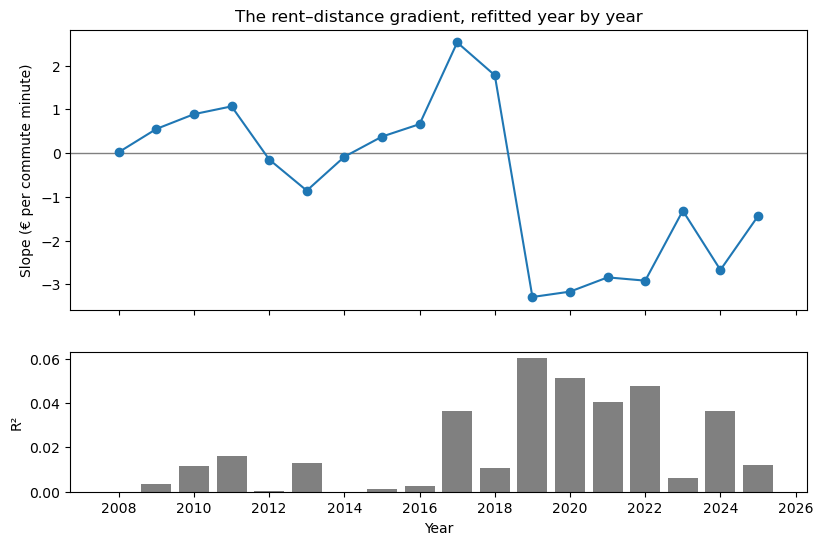

,year,eur_per_minute,implied_centre_rent,r_squared,stations,eur_per_stop
0,2008,0.02,1303.64,0.00,19,0.04
1,2009,0.55,1179.32,0.00,24,1.01
2,2010,0.89,1059.50,0.01,24,1.62
3,2011,1.07,1024.57,0.02,24,1.95
4,2012,-0.15,1069.69,0.00,24,-0.27
5,2013,-0.86,1124.07,0.01,24,-1.57
6,2014,-0.09,1196.17,0.00,24,-0.16
7,2015,0.38,1312.92,0.00,24,0.69
8,2016,0.66,1431.31,0.00,24,1.21
9,2017,2.53,1503.81,0.04,24,4.62


In [6]:
station_rents = run_sql("SELECT * FROM station_rents")
g = gradient_by_year(station_rents)
g["eur_per_stop"] = g["eur_per_minute"].map(eur_per_stop)

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(9.5, 6), sharex=True,
                               gridspec_kw={"height_ratios": [2, 1]})
ax1.axhline(0, color="grey", linewidth=1)
ax1.plot(g["year"], g["eur_per_minute"], marker="o")
ax1.set_ylabel("Slope (€ per commute minute)")
ax1.set_title("The rent–distance gradient, refitted year by year")
ax2.bar(g["year"], g["r_squared"], color="grey")
ax2.set_ylabel("R²")
ax2.set_xlabel("Year")
ax2.xaxis.set_major_locator(plt.MaxNLocator(integer=True))
save_fig(fig, "gradient_by_year")
plt.show()

g.round(2)

**This is the project's main (and honestly, unexpected) finding.** The
slope wobbles around zero for the whole 18 years and the R² never exceeds
0.06. On the Green Line, the textbook rent–distance gradient simply does
not exist — and never has in the RTB data.

The economic reading: this corridor runs through uniformly affluent areas
from end to end (Dublin 2 → Ranelagh → Dundrum → Sandyford →
Carrickmines/Foxrock). Rent is set by the *area*, not by the commute.
A renter is not paid to move outward here, the way classic bid-rent
theory predicts — living 42 minutes out in Brides Glen saves only about
€350/month on a 1–2 bed versus the city centre.

## 4. Value for money, and the price cliffs

If the gradient is flat *on average*, the bargains are in the
station-level deviations. Two SQL queries do the work.

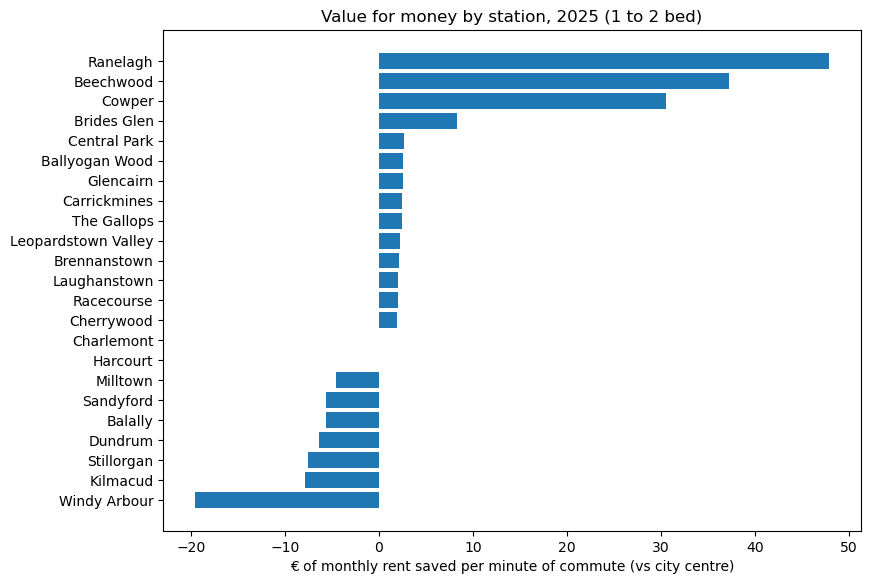

,station,commute_min,rent_1to2bed,monthly_saving,saving_per_minute
0,Ranelagh,7,1784.0,335.0,47.9
1,Beechwood,9,1784.0,335.0,37.2
2,Cowper,11,1784.0,335.0,30.5
3,Brides Glen,42,1772.0,347.0,8.3
4,Central Park,26,2050.0,69.0,2.7
5,Ballyogan Wood,33,2032.0,87.0,2.6


In [7]:
value = run_query_file("09")

fig, ax = plt.subplots(figsize=(9, 6.5))
ordered = value.sort_values("saving_per_minute")
ax.barh(ordered["station"], ordered["saving_per_minute"])
ax.set_xlabel("€ of monthly rent saved per minute of commute (vs city centre)")
ax.set_title(f"Value for money by station, 2025 ({SLICE})")
save_fig(fig, "value_for_money")
plt.show()

value.head(6)

The Ranelagh cluster is the runaway winner: **€48 saved per commute
minute** at Ranelagh itself, more than five times any station beyond
Milltown. The far end of the line (Brides Glen, €8.3/min) beats every
mid-line station, which is why it kept winning the "cheapest stop of the
year" query (17) since records began — but the absolute saving is modest.

In [8]:
cliffs = run_query_file("08")
cliffs.head(8)

,between_stops,rent_change_eur
0,Cowper -> Milltown,396.0
1,Charlemont -> Ranelagh,-335.0
2,Cherrywood -> Brides Glen,-268.0
3,Milltown -> Windy Arbour,233.0
4,Sandyford -> Central Park,-203.0
5,Windy Arbour -> Dundrum,-185.0
6,Balally -> Kilmacud,58.0
7,Stillorgan -> Sandyford,-33.0


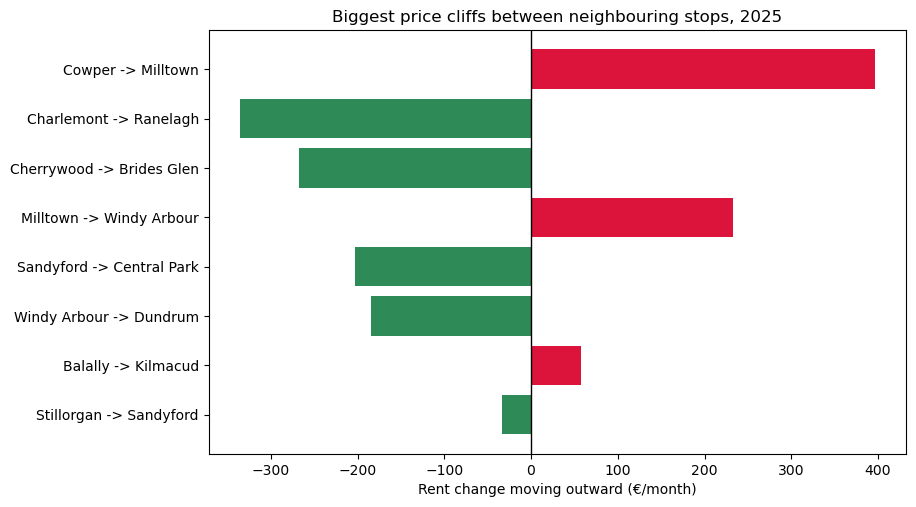

In [9]:
fig, ax = plt.subplots(figsize=(9, 5.5))
top = cliffs.head(8).iloc[::-1]
colors = ["crimson" if v > 0 else "seagreen" for v in top["rent_change_eur"]]
ax.barh(top["between_stops"], top["rent_change_eur"], color=colors)
ax.axvline(0, color="black", linewidth=1)
ax.set_xlabel("Rent change moving outward (€/month)")
ax.set_title("Biggest price cliffs between neighbouring stops, 2025")
save_fig(fig, "price_cliffs")
plt.show()

The single biggest cliff is **Cowper → Milltown: +€396/month** for one
stop further *out* — driven by Milltown's newer, more upmarket apartment
stock. Going the other way, crossing from Charlemont into Ranelagh saves
€335. Riding one extra stop can matter far more than the 18-station
average suggests.

## 5. Map

Stations coloured by 2025 1–2 bed rent (green = cheaper). Saved to
`reports/figures/rent_map.html` for the README and reused by the
Streamlit app.

In [10]:
stations = pd.read_csv(ROOT / "data" / "luas_stations.csv")
rent_2025 = run_sql(f"""
    SELECT station, avg_rent
    FROM station_rents
    WHERE year = 2025 AND bedrooms = '{SLICE}'
      AND property_type = 'All property types'
""")
mapped = stations.merge(rent_2025, on="station")

fmap = station_rent_map(mapped)
save_map(fmap, "rent_map")
fmap

## Conclusions

1. **The headline average misleads.** Unadjusted, the suburbs look as
   expensive as the city centre; that is housing-mix, not geography.
   Like-for-like (1–2 bed), the centre costs more — but not much more.
2. **There is no rent–distance gradient on the Green Line.** Slope
   ≈ −€1.4 per commute minute in 2025 with R² = 0.01, and no year since
   2008 looks any different. Area, not commute, sets the rent on this
   corridor.
3. **Best value: the Ranelagh cluster** (€1,784/month, 7–11 min out,
   €48 saved per commute minute). Cheapest in absolute terms: Brides
   Glen, every single year since 2008.
4. **Price cliffs are real**: one stop (Cowper → Milltown) can cost an
   extra €396/month; Charlemont → Ranelagh saves €335.
5. The corridor as a whole has held a stable **15–19% premium** over the
   Dublin county average through crash, boom and Covid.

**Caveats.** RTB figures are averages of *registered tenancies* (new and
renewed), not asking prices; each station inherits the figure of its
suburb-level RTB area, so stations sharing an area are identical by
construction; scheduled travel times ignore waiting and walking; and the
Ranelagh dip deserves a closer look (older flat stock vs new builds)
before anyone signs a lease over it.